In [1]:
from myclass import *

#################################################
#------------------ Load Data ------------------#
#################################################

patient_info = pd.read_excel('Dataset.xlsx','patient_information',engine='openpyxl')
cnv_5mb_counts = pd.read_excel('Dataset.xlsx','cnv_5mb_counts',engine='openpyxl').loc[:,['patientID','cnv_Count']].rename(columns={'cnv_Count': 'cnv_Count_5mb'})
cnv_gistic_counts = pd.read_excel('Dataset.xlsx','cnv_gistic_counts',engine='openpyxl').loc[:,['patientID','cnv_Count']].rename(columns={'cnv_Count': 'cnv_Count_gistic'})
snv = pd.read_excel('Dataset.xlsx','snv_feature_matrix',engine='openpyxl')
clinical_info = pd.read_excel('Clinical Feature.xlsx','Supplementary Table 2',engine='openpyxl').drop(['Subject type', 'Subject group', 'Stage (AJCC v7)', 'Pack-years'], axis=1)
clinical_info = clinical_info.rename(columns={'Histology':'Histology label'})

In [2]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

seed = 1105
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

## Data

In [3]:
##################################################
#-------------- Data Preprocessing -------------#
################################################

#----- Parameters -----#
num_patients_train = len(patient_info[patient_info.split_info == 'training'])# number of patients in training set
num_patients_test = len(patient_info[patient_info.split_info == 'validation'])# number of patients in training set
max_variats = 84 # max number of variation for each patient
num_steps = 84
# num_feature_not_snv = 8
num_var_attri = snv.shape[1] # number of attributes to discribe each variation
scale = Normalization('MinMaxLogScale') # choose normalizer

# #----- OneHot categorical variable of SNV-----#
one_hot,_,_ = OneHotText(snv['Gene'])
snv['Gene'] = [one_hot[i] for i in range(len(one_hot))]


one_hot,_,_ = OneHotText(snv['Variant.type'])
snv['Variant.type'] = [one_hot[i] for i in range(len(one_hot))]

snv['BaseConversion'] = snv['Tumor.allele']+snv['Ref..allele']
one_hot,_,_ = OneHotText(snv['BaseConversion'])
snv['BaseConversion'] = [one_hot[i] for i in range(len(one_hot))]

one_hot,_,_ = OneHotText(snv['Chr'])
snv['Chr'] = [one_hot[i] for i in range(len(one_hot))]

one_hot,_,_ = OneHotText(snv['germline_reads'])
snv['germline_reads'] = [one_hot[i] for i in range(len(one_hot))]

# drop coded feature
snv = snv.drop(['Tumor.allele', 'Ref..allele', 'variant', 'lookup', 
                'Case', 'cohort', 'A>CUnstranded', 'A>GUnstranded',
                'A>TUnstranded', 'C>AUnstranded', 'C>GUnstranded', 
                'G>AUnstranded', 'pass_basic_QC', 'blacklist1_oncogenes',
                'pass_basic_QC_coding'], axis=1)

# snv feature list to scale
list_to_normalization = ['Position','Percent.mutant.allele', 'variant_count_norm','ontarget_shoulder_tile_mut_count_norm', 
                         'duplex_reads', 'germline_NumNonZeroMeanAF_Pval', 'mean_bc_family_size', 'watsoncrickfisher.p',
                         'mean_total_bc_errors_corrected', 'mean_norm_varpos', 'mean_var_phred_score', 'mean_num_non_ref_bases',
                         'fraction_MapQmin30', 'variant_norm_bc_fam_size', 'normalized_depth','gnomad_maxAF',
                         'size_selected_adjustment','germlinebg_Bayesian_pval', 'cfdnabg_Bayesian_pval',
                         'sum_log10_frag_size_enrich_score', 'germline_depth_at_position', 'cosmic_total_count', 'cosmic_lung_count']



In [4]:
snv_before = deepcopy(snv)

In [5]:
#----- OneHot categorical variable of clinical features ----#
clinical_info = pd.read_excel('Clinical Feature.xlsx','Supplementary Table 2',engine='openpyxl').drop(['Subject type', 'Subject group', 'Stage (AJCC v7)', 'Pack-years'], axis=1)
clinical_info = clinical_info.rename(columns={'Histology':'Histology label'})

one_hot,_,_ = OneHotText(clinical_info['Sex'])
clinical_info['Sex'] = deepcopy(one_hot)

one_hot,_,_ = OneHotText(clinical_info['Histology label'])
clinical_info['Histology label'] = deepcopy(one_hot)

one_hot,_,_ = OneHotText(clinical_info['Smoker'])
clinical_info['Smoker'] = deepcopy(one_hot)

In [6]:
dataset = patient_info.set_index('patientID').\
join(cnv_5mb_counts.set_index('patientID')).join(cnv_gistic_counts.set_index('patientID')).drop('SampleID', axis=1).\
join(clinical_info.set_index('Patient ID'))

In [7]:
##################################################
#-------------- Obtain Training Set -------------#
################################################
train_x = deepcopy(dataset[dataset.split_info == 'training'])

#----- clinical features normalization -----#
clinical_list_to_normalization = ['Age (years)', 'Plasma volume used', 'Plasma cfDNA concentration (ng/mL)', 'Plasma DNA input (ng)']
train_x = normalizer(train_x, clinical_list_to_normalization, scale)
#----- cnv normalization -----#
cnv_list_to_normalization = ['cnv_Count_5mb','cnv_Count_gistic']
train_x = normalizer(train_x, cnv_list_to_normalization, scale)
#----- snv normalization -----#
train_snv = deepcopy(snv[['SU2'not in i for i in snv['patientID']]])
train_snv = normalizer(train_snv, list_to_normalization, scale)
train_x = GroupAndExtractSNV(train_x, train_snv, num_steps)
    
#----- Label -----#    
train_x['label'] = [1 if 'LUP' in train_x.index[i] else 0 for i in range(train_x.shape[0])]
one_hot,_,_ = OneHotText(train_x['Stage_group'])
train_x['stage_label'] = [one_hot[i] for i in range(len(one_hot))]
train_x = train_x.drop(['Stage_group'], axis=1) 

In [8]:
train_x_before = deepcopy(train_x)

In [9]:
##################################################
#-------------- Obtain Test Set -------------#
################################################

test_x = deepcopy(dataset[dataset.split_info == 'validation'])

#----- clinical features normalization -----#
test_x = normalizer(test_x, clinical_list_to_normalization, scale)
#----- cnv normalization -----#
test_x = normalizer(test_x, cnv_list_to_normalization, scale)
#----- snv normalization -----#
test_snv = deepcopy(snv[['SU2' in i for i in snv['patientID']]])
test_snv = normalizer(test_snv, list_to_normalization, scale)
test_x = GroupAndExtractSNV(test_x, test_snv, num_steps)
    
#----- Label -----#    
test_x['label'] = [1 if 'SU2CS' in test_x.index[i] else 0 for i in range(test_x.shape[0])]
one_hot,_,_ = OneHotText(test_x['Stage_group'])
test_x['stage_label'] = [one_hot[i] for i in range(len(one_hot))]
test_x = test_x.drop(['Stage_group'], axis=1)

# AutoML based on Baysian optimization

In [10]:
class AutoBiLSTMModel(nn.Module):
    """
    Class description: only Dropout on LSTM & FC no batch norm, bidirectional Long Short-term memory model
    
    """
    #----- Define all layers -----#
    def __init__(self, num_inputs_lstm, num_lstm_hiddens, num_lstm_layers, lstm_bidirectional, initial_dropout,
               num_feature_not_snv, num_output_nodes, num_fc_layers, device, act = nn.Sigmoid(), **kwargs):
        super(AutoBiLSTMModel, self).__init__(**kwargs)
        
        #--- LSTM layer ---#
        if num_lstm_layers == 1:
            lstm_dropout = 0
        else:
            lstm_dropout = initial_dropout
        self.lstm = nn.LSTM(num_inputs_lstm,
                            num_lstm_hiddens,
                            num_layers=num_lstm_layers,
                            bidirectional=lstm_bidirectional,
                            dropout=lstm_dropout,
                            batch_first=True)
        #--- Fully connected layers ---#
        self.num_fc_layers = num_fc_layers
        num_fc_input = num_lstm_hiddens * 2+num_feature_not_snv
        if num_fc_layers == 1:
            self.fc0 = nn.Linear(num_fc_input, num_output_nodes)
        else:
            # the first fc layer
            self.fc0 = nn.Linear(num_fc_input, int(ceil(num_fc_input/2)))
            self.dropout0 = nn.Dropout(1.1*initial_dropout)
            if num_fc_layers == 2:
                # the last fc layer when num_fc_layers == 2
                self.fc1 = nn.Linear(int(ceil(num_fc_input/2)), num_output_nodes)
            else:
                # the middle fc layer
                for i in range(1,num_fc_layers-1):
                    tmp_input = int(ceil(num_fc_input/2**i))
                    tmp_output = int(ceil(num_fc_input/2**(i+1)))
                    exec('self.fc{} = nn.Linear(tmp_input, tmp_output)'.format(i))
                    if i < ceil(num_fc_layers/2) and 1.1**(i+1)*initial_dropout < 1:
                        exec('self.dropout{} = nn.Dropout(1.1**(i+1)*initial_dropout)'.format(i))
                    elif i >= ceil(num_fc_layers/2) and 1.1**(num_fc_layers-1-i)*initial_dropout < 1:
                        exec('self.dropout{} = nn.Dropout(1.1**(num_fc_layers-1-i)*initial_dropout)'.format(i))
                    else:
                        exec('self.dropout{} = nn.Dropout(0.5)'.format(i))
                # the last fc layer
                exec('self.fc{} = nn.Linear(tmp_output, num_output_nodes)'.format(i+1))
            
        #--- Activation function ---#
        self.act = act
    
    #----- Forward -----#
    def forward(self, x_snv, x_other):
        # x_snv size:  [batch size, sent_length, feature_dim]
        #--- BatchNorm layer ---#
#         norm_output = self.norm(x_snv.permute(0,2,1))
        norm_output = x_snv.permute(0,2,1)
        #--- LSTM layer ---#
        lstm_output, (hidden_state, cell) = self.lstm(norm_output.permute(0,2,1))# hidden size:  [num layersa * num directions, batch size, hid dim]
        #--- Fully connected layers ---#
        #--- Joins the final forward and reverse hidden states ---#
        hidden_state = torch.cat((hidden_state[-2,:,:], hidden_state[-1,:,:]), dim = 1)
        hidden_dense = torch.cat((hidden_state, x_other), dim = 1)
        
        if self.num_fc_layers == 1:
            outputs = self.fc0(hidden_dense)
        else:
            # the first fc layer
            outputs = self.act(self.dropout0(self.fc0(hidden_dense)))
            if self.num_fc_layers == 2:
                # the last fc layer when num_fc_layers == 2
                outputs = self.fc1(outputs)
            else:
                # the middle fc layer
                for i in range(1,self.num_fc_layers-1):
                    outputs = eval('self.act(self.dropout{}(self.fc{}(outputs)))'.format(i,i))
                # the last fc layer
                outputs = eval('self.fc{}(outputs)'.format(i+1))
            
        return outputs.softmax(dim=1)

In [11]:
def train_val_test(num_inputs_lstm, num_lstm_hiddens, num_lstm_layers, lstm_bidirectional, lstm_dropout, num_feature_not_snv, num_fc_layers,
                   batch_size, lr, patience, num_outer_split, frac_inner_val, train_x, num_epochs, device):
    train_kf = []
    val_kf = []
    test_kf = []
    KF = StratifiedKFold(num_outer_split, shuffle=True)
    for train_index, sub_test_index in KF.split(train_x, train_x['label']):
        sub_train_index, sub_val_index = next(StratifiedShuffleSplit(n_splits=1,test_size=frac_inner_val).
                                               split(train_x.iloc[train_index],train_x.iloc[train_index]['label']))

        #---  Seperate traing set, validation set and test set ---#
        sub_train = Resampler(train_x.iloc[sub_train_index][:], train_x.iloc[sub_train_index]['label'])
        train_iter = BatchDataGeneration(sub_train, batch_size, shuffle=True)
        val_iter = BatchDataGeneration(train_x.iloc[sub_val_index][:], batch_size, shuffle=True)
        test_iter = BatchDataGeneration(train_x.iloc[sub_test_index][:], batch_size, shuffle=True)


        #-----  Instantiate model -----#
        # setting 'lstm_bidirectional=True'to define Bidirectional LSTM model
        model = AutoBiLSTMModel(num_inputs_lstm, num_lstm_hiddens, num_lstm_layers, lstm_bidirectional, lstm_dropout,
                   num_feature_not_snv, num_output_nodes, num_fc_layers, device)
        model = model.to(device)

        model.apply(init_weights)

        #-----  Loss -----#
        loss = nn.CrossEntropyLoss(reduction="none")
        loss = loss.to(device)

        #--- Define optimizer ---#
        optimizer = torch.optim.Adam(model.parameters(), lr)
        
        #-----  Instantiate EarlyStopping -----#
        early_stopping = EarlyStopping(patience, verbose=False)

        train_loss, train_acc, train_auc, train_speed, val_loss, val_acc, val_auc = train_evaluate(
            model, train_iter, val_iter, loss, optimizer, early_stopping, num_epochs, device)
        
        model.eval()
        test_loss, test_acc, test_auc = evaluate(model, test_iter, loss, device)
        train_kf.append([train_loss, train_acc, train_auc, train_speed])
        val_kf.append([val_loss, val_acc, val_auc])
        test_kf.append([test_loss, test_acc, test_auc])
    return train_kf, val_kf, test_kf

In [12]:
# ---------------------------------------------------#   
#    Parameter Tuning with Bayesian optimization    #
#--------------------------------------------------# 
num_outer_split = 5
frac_inner_val = 0.25

num_output_nodes, num_epochs = 2, 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


lstm_bidirectional = True
best_score = 100
batch_size = 64



snv_to_select = snv.drop('patientID', axis=1).columns
other_feature_to_select = train_x.drop(['split_info', 'Histology label', 'label', 'stage_label', 'snv'], axis=1).columns
num_feature_to_select = len(snv_to_select) + len(other_feature_to_select)

##---   Define search space   ---##
# The list of hyper-parameters we want to optimize. For each one we define the
# bounds, the corresponding parameter name, as well as how to
# sample values from that dimension (`'log-uniform'` for the learning rate)

search_spaces = [Integer(1,2**10-1, name = 'first_group_selected_features'),
                 Integer(1,2**10-1, name = 'second_group_selected_features'),
                 Integer(1,2**10-1, name = 'third_group_selected_features'),
                 Integer(1,2**7-1, name = 'forth_group_selected_features'),
                 Integer(1,2**9-1, name = 'other_selected_features'),
                 Integer(1,10, name = 'num_lstm_layers'),
                 Real(1e-1, 0.5, prior='log-uniform', name = 'lstm_dropout'),
                 Categorical([64,128,256,512], transform = 'identity', name = 'num_lstm_hiddens'),
                 Real(1e-3, 1e-1, prior='log-uniform', name = 'lr'),
                 Integer(1,10, name = 'patience'),
                 Integer(1,10, name = 'num_fc_layers')
                ]

@use_named_args(search_spaces)
def masked_objective(first_group_selected_features, second_group_selected_features, third_group_selected_features, forth_group_selected_features,
                     other_selected_features, num_lstm_layers, lstm_dropout, num_lstm_hiddens, lr, patience, num_fc_layers):
    global best_score, snv_to_select, other_feature_to_select
    
    #---   Decoding feature selection results   ---#
    bin_selected_features = bin(first_group_selected_features)[2:]
    for i in range(10-len(bin_selected_features)):
        bin_selected_features = '0' + bin_selected_features
        
    tmp_bin_selected_features = bin(second_group_selected_features)[2:]
    for i in range(10-len(tmp_bin_selected_features)):
        tmp_bin_selected_features = '0' + tmp_bin_selected_features
    bin_selected_features = bin_selected_features+ tmp_bin_selected_features
    
    tmp_bin_selected_features = bin(third_group_selected_features)[2:]
    for i in range(10-len(tmp_bin_selected_features)):
        tmp_bin_selected_features = '0' + tmp_bin_selected_features
    bin_selected_features = bin_selected_features+ tmp_bin_selected_features
    
    tmp_bin_selected_features = bin(forth_group_selected_features)[2:]
    for i in range(7-len(tmp_bin_selected_features)):
        tmp_bin_selected_features = '0' + tmp_bin_selected_features
    bin_selected_features = bin_selected_features+ tmp_bin_selected_features
    
    snv_selected = [snv_to_select[i] for i in range(len(snv_to_select)) if bin_selected_features[i] == '1']
    snv_selected.append('patientID')
    
    bin_selected_features = bin(other_selected_features)[2:]
    for i in range(9-len(bin_selected_features)):
        bin_selected_features = '0' + bin_selected_features
        
    
    other_feature_selected = [other_feature_to_select[i] for i in range(len(other_feature_to_select)) if bin_selected_features[i] == '1']
    other_feature_selected.append('label')
    
    new_train_snv = deepcopy(train_snv[snv_selected])
    new_train_x = deepcopy(train_x[other_feature_selected])
    new_train_x = NewGroupAndExtractSNV(new_train_x, new_train_snv, num_steps)
    
    num_inputs_lstm = new_train_x.iloc[0]['snv'].shape[1]
    
    num_feature_not_snv = len(other_feature_selected)-1
    
    train_all, val_all, test_all = train_val_test(num_inputs_lstm, num_lstm_hiddens, num_lstm_layers, lstm_bidirectional, lstm_dropout, 
                                                  num_feature_not_snv, num_fc_layers, batch_size, lr, patience, num_outer_split, frac_inner_val,
                                                  new_train_x, num_epochs, device)
        
    train_all = np.array(train_all)
    val_all = np.array(val_all)
    test_all = np.array(test_all)
    train_loss, train_acc, train_auc, train_speed = train_all[:,0], train_all[:,1], train_all[:,2], train_all[:,3]
    val_loss, val_acc, val_auc = val_all[:,0], val_all[:,1], val_all[:,2]
    test_loss, test_acc, test_auc = test_all[:,0], test_all[:,1], test_all[:,2]    
    print('-'*20)
    print('One layer without smote without mask with early stopping under k-fold cv best model:')
    print('-'*20)
    print(f'On training set: Loss {train_loss.mean():.3f}, Accuracy {train_acc.mean():.3f}, Auc {train_auc.mean():.3f}, {train_speed.mean():.1f} samples/s {str(device)}.')
    print(f'On validation set: Loss {val_loss.mean():.3f}, Accuracy {val_acc.mean():.3f}, Auc {val_auc.mean():.3f}.')
    print(f'On test set: Loss {test_loss.mean():.3f}, Accuracy {test_acc.mean():.3f}, Auc {test_auc.mean():.3f}.')
    
    train_score = -train_auc.mean()
    val_score = -val_auc.mean()
    test_score = -test_auc.mean()
    
    tmp = val_score+test_score
    
    if tmp < best_score:
        best_score = tmp
        print('*'*20)
        print("""Best parameters:
        snv_selected = %s
        other_feature_selected = %s
        num_lstm_layers = %d
        lstm_dropout = %f
        num_lstm_hiddens = %d
        lr = %f
        patience = %d
        num_fc_layers = %d""" % (snv_selected, other_feature_selected, num_lstm_layers, lstm_dropout, num_lstm_hiddens, lr, patience, num_fc_layers))
        print('*'*20)
    else:
        print("""Current parameters:
        snv_selected = %s
        other_feature_selected = %s
        num_lstm_layers = %d
        lstm_dropout = %f
        num_lstm_hiddens = %d
        lr = %f
        patience = %d
        num_fc_layers = %d""" % (snv_selected, other_feature_selected, num_lstm_layers, lstm_dropout, num_lstm_hiddens, lr, patience, num_fc_layers))
        
    frac_feature = 0.05*(len(other_feature_selected) - 1)/ len(other_feature_to_select)+ 0.01*len(snv_selected)/len(snv_to_select)
    
    return (0.5*tmp + frac_feature)


In [13]:
t = time.localtime()
print(str(t.tm_hour)+':'+str(t.tm_min))

17:10


Iteration No: 1 started. Evaluating function at random point.
--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.694, Accuracy 0.498, Auc 0.522, 65.8 samples/s cuda.
On validation set: Loss 0.693, Accuracy 0.456, Auc 0.500.
On test set: Loss 0.695, Accuracy 0.400, Auc 0.500.
********************
Best parameters:
        snv_selected = ['Gene', 'ontarget_shoulder_tile_mut_count_norm', 'pass_split_1yes', 'duplex_reads', 'germline_NumNonZeroMeanAF_Pval', 'mean_bc_family_size', 'watsoncrickfisher.p', 'mean_total_bc_errors_corrected', 'mean_norm_varpos', 'mean_num_non_ref_bases', 'normalized_depth', 'gnomad_maxAF', 'size_selected_adjustment', 'pass_basic_QC_nonsynon_lungdriver', 'pass_basic_QC_nonsynon_lungdriver_hotspot', 'sum_log10_frag_size_enrich_score', 'germline_reads', 'tumor_adjudicated', 'cosmic_total_count', 'intersect_unpadded_selector', 'blacklist3tumorsupressor', 'BaseConversion'

--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.694, Accuracy 0.496, Auc 0.507, 338.6 samples/s cuda.
On validation set: Loss 0.693, Accuracy 0.519, Auc 0.596.
On test set: Loss 0.690, Accuracy 0.588, Auc 0.676.
Current parameters:
        snv_selected = ['Variant.type', 'Position', 'Gene', 'Percent.mutant.allele', 'variant_count_norm', 'pass_split_1yes', 'duplex_reads', 'mean_bc_family_size', 'mean_total_bc_errors_corrected', 'mean_norm_varpos', 'mean_var_phred_score', 'fraction_MapQmin30', 'variant_norm_bc_fam_size', 'gnomad_maxAF', 'base_change_transition', 'cfdnabg_Bayesian_pval', 'germline_reads', 'cosmic_total_count', 'has_matched_tumor', 'intersect_unpadded_selector', 'cosmic_lung_count', 'blacklist3tumorsupressor', 'patientID']
        other_feature_selected = ['cnv_Count_gistic', 'Age (years)', 'Sex', 'Plasma DNA input (ng)', 'label']
        num_lstm_layers = 2
        lstm_

Iteration No: 14 ended. Search finished for the next optimal point.
Time taken: 178.0147
Function value obtained: -0.8014
Current minimum: -0.8673
Iteration No: 15 started. Searching for the next optimal point.
--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.622, Accuracy 0.640, Auc 0.677, 98.3 samples/s cuda.
On validation set: Loss 0.610, Accuracy 0.619, Auc 0.909.
On test set: Loss 0.597, Accuracy 0.650, Auc 0.838.
Current parameters:
        snv_selected = ['Variant.type', 'Chr', 'Gene', 'variant_count_norm', 'ontarget_shoulder_tile_mut_count_norm', 'pass_split_1yes', 'duplex_reads', 'mean_total_bc_errors_corrected', 'mean_num_non_ref_bases', 'variant_norm_bc_fam_size', 'normalized_depth', 'gnomad_maxAF', 'germline_depth_at_position', 'intersect_unpadded_selector', 'cosmic_lung_count', 'blacklist3tumorsupressor', 'patientID']
        other_feature_selected = ['snv_valid_len', 'lab

Iteration No: 21 ended. Search finished for the next optimal point.
Time taken: 991.9984
Function value obtained: -0.8129
Current minimum: -0.8673
Iteration No: 22 started. Searching for the next optimal point.
--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.685, Accuracy 0.523, Auc 0.548, 30.6 samples/s cuda.
On validation set: Loss 0.710, Accuracy 0.431, Auc 0.672.
On test set: Loss 0.702, Accuracy 0.388, Auc 0.711.
Current parameters:
        snv_selected = ['Variant.type', 'Chr', 'Gene', 'ontarget_shoulder_tile_mut_count_norm', 'pass_split_1yes', 'germline_NumNonZeroMeanAF_Pval', 'gnomad_maxAF', 'germline_depth_at_position', 'cosmic_total_count', 'patientID']
        other_feature_selected = ['cnv_Count_gistic', 'Sex', 'Plasma DNA input (ng)', 'label']
        num_lstm_layers = 10
        lstm_dropout = 0.132968
        num_lstm_hiddens = 128
        lr = 0.001296
        patience

Iteration No: 28 ended. Search finished for the next optimal point.
Time taken: 71.3781
Function value obtained: -0.8170
Current minimum: -0.8673
Iteration No: 29 started. Searching for the next optimal point.
--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.508, Accuracy 0.806, Auc 0.847, 225.8 samples/s cuda.
On validation set: Loss 0.565, Accuracy 0.750, Auc 0.762.
On test set: Loss 0.491, Accuracy 0.819, Auc 0.839.
Current parameters:
        snv_selected = ['Variant.type', 'Position', 'ontarget_shoulder_tile_mut_count_norm', 'duplex_reads', 'mean_norm_varpos', 'gnomad_maxAF', 'LUNG_driver', 'pass_basic_QC_nonsynon_lungdriver', 'pass_basic_QC_nonsynon_lungdriver_hotspot', 'germlinebg_Bayesian_pval', 'cfdnabg_Bayesian_pval', 'tumor_adjudicated', 'cosmic_total_count', 'has_matched_tumor', 'intersect_unpadded_selector', 'cosmic_lung_count', 'blacklist3tumorsupressor', 'BaseConversion'

...

Iteration No: 69 ended. Search finished for the next optimal point.
Time taken: 17.9164
Function value obtained: -0.5621
Current minimum: -0.8673
Iteration No: 70 started. Searching for the next optimal point.
--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.560, Accuracy 0.751, Auc 0.782, 119.2 samples/s cuda.
On validation set: Loss 0.617, Accuracy 0.688, Auc 0.676.
On test set: Loss 0.541, Accuracy 0.775, Auc 0.750.
Current parameters:
        snv_selected = ['germline_NumNonZeroMeanAF_Pval', 'mean_norm_varpos', 'fraction_MapQmin30', 'variant_norm_bc_fam_size', 'normalized_depth', 'base_change_transition', 'size_selected_adjustment', 'pass_basic_QC_nonsynon_lungdriver_hotspot', 'germlinebg_Bayesian_pval', 'germline_depth_at_position', 'cosmic_lung_count', 'BaseConversion', 'patientID']
        other_feature_selected = ['snv_valid_len', 'label']
        num_lstm_layers = 4
        ls

Iteration No: 76 ended. Search finished for the next optimal point.
Time taken: 171.8196
Function value obtained: -0.8165
Current minimum: -0.8673
Iteration No: 77 started. Searching for the next optimal point.
--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.644, Accuracy 0.683, Auc 0.749, 219.6 samples/s cuda.
On validation set: Loss 0.678, Accuracy 0.581, Auc 0.798.
On test set: Loss 0.661, Accuracy 0.619, Auc 0.840.
Current parameters:
        snv_selected = ['Variant.type', 'Chr', 'Position', 'Gene', 'Percent.mutant.allele', 'variant_count_norm', 'ontarget_shoulder_tile_mut_count_norm', 'pass_split_1yes', 'duplex_reads', 'germline_NumNonZeroMeanAF_Pval', 'mean_bc_family_size', 'watsoncrickfisher.p', 'mean_total_bc_errors_corrected', 'mean_norm_varpos', 'mean_num_non_ref_bases', 'fraction_MapQmin30', 'base_change_transition', 'pass_basic_QC_nonsynon_lungdriver', 'germlinebg_Bayesia

Iteration No: 83 ended. Search finished for the next optimal point.
Time taken: 88.7971
Function value obtained: -0.8689
Current minimum: -0.8689
Iteration No: 84 started. Searching for the next optimal point.
--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.538, Accuracy 0.767, Auc 0.781, 534.5 samples/s cuda.
On validation set: Loss 0.551, Accuracy 0.769, Auc 0.834.
On test set: Loss 0.532, Accuracy 0.787, Auc 0.859.
Current parameters:
        snv_selected = ['germline_NumNonZeroMeanAF_Pval', 'mean_bc_family_size', 'mean_norm_varpos', 'mean_var_phred_score', 'fraction_MapQmin30', 'variant_norm_bc_fam_size', 'normalized_depth', 'gnomad_maxAF', 'size_selected_adjustment', 'pass_basic_QC_nonsynon_lungdriver_hotspot', 'germline_depth_at_position', 'tumor_adjudicated', 'cosmic_total_count', 'has_matched_tumor', 'cosmic_lung_count', 'blacklist3tumorsupressor', 'BaseConversion', 'patientID

--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.529, Accuracy 0.761, Auc 0.803, 738.1 samples/s cuda.
On validation set: Loss 0.571, Accuracy 0.713, Auc 0.859.
On test set: Loss 0.538, Accuracy 0.713, Auc 0.884.
Current parameters:
        snv_selected = ['germline_NumNonZeroMeanAF_Pval', 'mean_bc_family_size', 'watsoncrickfisher.p', 'mean_total_bc_errors_corrected', 'mean_var_phred_score', 'variant_norm_bc_fam_size', 'normalized_depth', 'base_change_transition', 'LUNG_driver', 'pass_basic_QC_nonsynon_lungdriver_hotspot', 'germlinebg_Bayesian_pval', 'cfdnabg_Bayesian_pval', 'germline_depth_at_position', 'tumor_adjudicated', 'cosmic_total_count', 'has_matched_tumor', 'intersect_unpadded_selector', 'blacklist3tumorsupressor', 'patientID']
        other_feature_selected = ['snv_valid_len', 'label']
        num_lstm_layers = 1
        lstm_dropout = 0.131446
        num_lstm_hiddens = 128

Iteration No: 96 ended. Search finished for the next optimal point.
Time taken: 43.3049
Function value obtained: -0.8346
Current minimum: -0.8689
Iteration No: 97 started. Searching for the next optimal point.
--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.513, Accuracy 0.803, Auc 0.853, 295.0 samples/s cuda.
On validation set: Loss 0.504, Accuracy 0.806, Auc 0.877.
On test set: Loss 0.522, Accuracy 0.787, Auc 0.854.
Current parameters:
        snv_selected = ['germline_NumNonZeroMeanAF_Pval', 'mean_total_bc_errors_corrected', 'mean_norm_varpos', 'mean_var_phred_score', 'gnomad_maxAF', 'base_change_transition', 'size_selected_adjustment', 'pass_basic_QC_nonsynon_lungdriver', 'sum_log10_frag_size_enrich_score', 'germline_depth_at_position', 'cosmic_total_count', 'has_matched_tumor', 'intersect_unpadded_selector', 'blacklist3tumorsupressor', 'patientID']
        other_feature_selected 

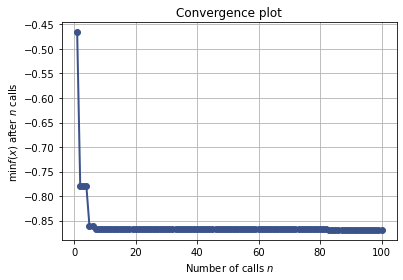

In [14]:
masked_gp = gp_minimize(masked_objective, search_spaces, n_calls=100, random_state=920,acq_func="EI",verbose=True, n_jobs=-1)

"Best score=%.4f" % masked_gp.fun

#---   Decoding feature selection results   ---#
bin_selected_features = bin(masked_gp.x[0])[2:]
for i in range(10-len(bin_selected_features)):
    bin_selected_features = '0' + bin_selected_features

tmp_bin_selected_features = bin(masked_gp.x[1])[2:]
for i in range(10-len(tmp_bin_selected_features)):
    tmp_bin_selected_features = '0' + tmp_bin_selected_features
bin_selected_features = bin_selected_features+ tmp_bin_selected_features

tmp_bin_selected_features = bin(masked_gp.x[2])[2:]
for i in range(10-len(tmp_bin_selected_features)):
    tmp_bin_selected_features = '0' + tmp_bin_selected_features
bin_selected_features = bin_selected_features+ tmp_bin_selected_features

tmp_bin_selected_features = bin(masked_gp.x[3])[2:]
for i in range(7-len(tmp_bin_selected_features)):
    tmp_bin_selected_features = '0' + tmp_bin_selected_features
bin_selected_features = bin_selected_features+ tmp_bin_selected_features

snv_selected = [snv_to_select[i] for i in range(len(snv_to_select)) if bin_selected_features[i] == '1']

snv_selected.append('patientID')

bin_selected_features = bin(masked_gp.x[4])[2:]
for i in range(9-len(bin_selected_features)):
    bin_selected_features = '0' + bin_selected_features


other_feature_selected = [other_feature_to_select[i] for i in range(len(other_feature_to_select)) if bin_selected_features[i] == '1']
other_feature_selected.append('label')
##---   Print parameters   ---##
print("""Best parameters:
snv_selected = %s
other_feature_selected = %s
num_lstm_layers = %d
lstm_dropout = %f
num_lstm_hiddens = %d
lr = %f
patience = %d
num_fc_layers = %d""" % (snv_selected, other_feature_selected, masked_gp.x[5],masked_gp.x[6], masked_gp.x[7],
                    masked_gp.x[8], masked_gp.x[9], masked_gp.x[10]))
from skopt.plots import plot_convergence
fig = plt.figure()
ax1=plot_convergence(masked_gp)
t = time.localtime()
plt.savefig(str(t.tm_year)+'-'+str(t.tm_mon)+'-'+str(t.tm_mday)+'-'+str(t.tm_hour)+'-'+str(t.tm_min)+'AutoBi-LSTM.png')
plt.savefig(str(t.tm_year)+'-'+str(t.tm_mon)+'-'+str(t.tm_mday)+'-'+str(t.tm_hour)+'-'+str(t.tm_min)+'AutoBi-LSTM.eps')

In [15]:
len(snv_selected)

16

In [16]:
# ---------------------------------------------------#   
#    Parameter Tuning with Bayesian optimization    #
#--------------------------------------------------# 
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

num_outer_split = 5
seed = 1105

num_output_nodes, num_epochs = 2, 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_lstm_layers, lstm_dropout, num_lstm_hiddens, lr, patience = masked_gp.x[5], masked_gp.x[6], masked_gp.x[7], masked_gp.x[8], masked_gp.x[9]
num_fc_layers = masked_gp.x[10]


new_train_snv = deepcopy(train_snv[snv_selected])
new_train_x = deepcopy(train_x[other_feature_selected])
new_train_x = NewGroupAndExtractSNV(new_train_x, new_train_snv, num_steps)

new_test_snv = deepcopy(test_snv[snv_selected])
new_test_x = deepcopy(test_x[other_feature_selected])
new_test_x = NewGroupAndExtractSNV(new_test_x, new_test_snv, num_steps)

num_inputs_lstm = new_train_x.iloc[0]['snv'].shape[1]
num_feature_not_snv = len(other_feature_selected)-1

num_repeat = 100
frac_val = 0.25
train_all = []
val_all = []
test_all = []
for i in range(num_repeat):
    best_score = None
    sub_train_index, sub_val_index = next(StratifiedShuffleSplit(n_splits=1,test_size=frac_val).split(new_train_x,new_train_x['label']))

    #---  Seperate traing set, validation set and test set ---#
    sub_train = Resampler(new_train_x.iloc[sub_train_index][:], new_train_x.iloc[sub_train_index]['label'])
    train_iter = BatchDataGeneration(sub_train, batch_size, shuffle=True)
    val_iter = BatchDataGeneration(new_train_x.iloc[sub_val_index][:], batch_size, shuffle=True)
    test_iter = BatchDataGeneration(new_test_x, batch_size, shuffle=True)
    
    #-----  Instantiate model -----#
    model = AutoBiLSTMModel(num_inputs_lstm, num_lstm_hiddens, num_lstm_layers, lstm_bidirectional, lstm_dropout,
                   num_feature_not_snv, num_output_nodes, num_fc_layers, device)
    model = model.to(device)
    model.apply(init_weights)
    
    #-----  Loss -----#
    loss = nn.CrossEntropyLoss(reduction="none")
    loss = loss.to(device)

    #--- Define optimizer ---#
    optimizer = torch.optim.Adam(model.parameters(), lr)

    #-----  Instantiate EarlyStopping -----#
    early_stopping = EarlyStopping(patience, verbose=False)

    train_loss, train_acc, train_auc, train_speed, val_loss, val_acc, val_auc = train_evaluate(
        model, train_iter, val_iter, loss, optimizer, early_stopping, num_epochs, device)

    test_loss, test_acc, test_auc = evaluate(model, test_iter, loss, device)

    train_all.append([train_loss, train_acc, train_auc, train_speed])
    val_all.append([val_loss, val_acc, val_auc])
    test_all.append([test_loss, test_acc, test_auc])
    print('-'*20)
    print('num of repeat:', i)
    print('-'*20)
    print(f'On training set: Loss {train_loss:.3f}, Accuracy {train_acc:.3f}, Auc {train_auc:.3f}, {train_speed:.1f} samples/s {str(device)}.')
    print(f'On validation set: Loss {val_loss:.3f}, Accuracy {val_acc:.3f}, Auc {val_auc:.3f}.')
    print(f'On test set: Loss {test_loss:.3f}, Accuracy {test_acc:.3f}, Auc {test_auc:.3f}.')


train_all = np.array(train_all)
val_all = np.array(val_all)
test_all = np.array(test_all)

train_loss, train_acc, train_auc, train_speed = train_all[:,0], train_all[:,1], train_all[:,2], train_all[:,3]
val_loss, val_acc, val_auc = val_all[:,0], val_all[:,1], val_all[:,2]
test_loss, test_acc, test_auc = test_all[:,0], test_all[:,1], test_all[:,2]    
print('-'*20)
print('One layer without smote with mask with early stopping under k-fold cv best model:')
print('-'*20)
print(f'On training set: Loss {train_loss.mean():.3f}, Accuracy {train_acc.mean():.3f}, Auc {train_auc.mean():.3f}, {train_speed.mean():.1f} samples/s {str(device)}.')
print(f'On validation set: Loss {val_loss.mean():.3f}, Accuracy {val_acc.mean():.3f}, Auc {val_auc.mean():.3f}.')
print(f'On test set: Loss {test_loss.mean():.3f}, Accuracy {test_acc.mean():.3f}, Auc {test_auc.mean():.3f}.')

#-----  Save performance -----#
df = (('train_loss', 'train_acc', 'train_auc', 'train_speed', 'val_loss', 'val_acc', 'val_auc', 'test_loss', 'test_acc', 'test_auc'),  
      (train_loss, train_acc, train_auc, train_speed, val_loss, val_acc, val_auc, test_loss, test_acc, test_auc)  
      )
df = pd.DataFrame(df)
t = time.localtime()
file_name = 'AutoBi-LSTM_'+str(t.tm_year)+'-'+str(t.tm_mon)+'-'+str(t.tm_mday)+'-'+str(t.tm_hour)+'-'+str(t.tm_min)+'.xlsx' #(t.tm_year)
df.to_excel(file_name,index = False)

--------------------
num of repeat: 0
--------------------
On training set: Loss 0.515, Accuracy 0.801, Auc 0.782, 224.7 samples/s cuda.
On validation set: Loss 0.563, Accuracy 0.750, Auc 0.788.
On test set: Loss 0.674, Accuracy 0.638, Auc 0.699.
--------------------
num of repeat: 1
--------------------
On training set: Loss 0.709, Accuracy 0.577, Auc 0.570, 224.4 samples/s cuda.
On validation set: Loss 0.829, Accuracy 0.450, Auc 0.856.
On test set: Loss 0.725, Accuracy 0.564, Auc 0.721.
--------------------
num of repeat: 2
--------------------
On training set: Loss 0.578, Accuracy 0.724, Auc 0.741, 225.1 samples/s cuda.
On validation set: Loss 0.673, Accuracy 0.600, Auc 0.854.
On test set: Loss 0.652, Accuracy 0.638, Auc 0.682.
--------------------
num of repeat: 3
--------------------
On training set: Loss 0.646, Accuracy 0.622, Auc 0.660, 227.7 samples/s cuda.
On validation set: Loss 0.590, Accuracy 0.725, Auc 0.898.
On test set: Loss 0.662, Accuracy 0.606, Auc 0.722.
------------

--------------------
num of repeat: 34
--------------------
On training set: Loss 0.595, Accuracy 0.718, Auc 0.712, 213.7 samples/s cuda.
On validation set: Loss 0.686, Accuracy 0.625, Auc 0.732.
On test set: Loss 0.672, Accuracy 0.638, Auc 0.688.
--------------------
num of repeat: 35
--------------------
On training set: Loss 0.652, Accuracy 0.609, Auc 0.602, 218.8 samples/s cuda.
On validation set: Loss 0.596, Accuracy 0.750, Auc 0.809.
On test set: Loss 0.662, Accuracy 0.606, Auc 0.647.
--------------------
num of repeat: 36
--------------------
On training set: Loss 0.579, Accuracy 0.731, Auc 0.743, 219.4 samples/s cuda.
On validation set: Loss 0.726, Accuracy 0.575, Auc 0.838.
On test set: Loss 0.668, Accuracy 0.638, Auc 0.722.
--------------------
num of repeat: 37
--------------------
On training set: Loss 0.480, Accuracy 0.840, Auc 0.823, 220.9 samples/s cuda.
On validation set: Loss 0.563, Accuracy 0.750, Auc 0.786.
On test set: Loss 0.652, Accuracy 0.660, Auc 0.677.
--------

--------------------
num of repeat: 68
--------------------
On training set: Loss 0.649, Accuracy 0.609, Auc 0.621, 223.5 samples/s cuda.
On validation set: Loss 0.624, Accuracy 0.725, Auc 0.901.
On test set: Loss 0.655, Accuracy 0.606, Auc 0.716.
--------------------
num of repeat: 69
--------------------
On training set: Loss 0.500, Accuracy 0.814, Auc 0.819, 213.7 samples/s cuda.
On validation set: Loss 0.563, Accuracy 0.750, Auc 0.838.
On test set: Loss 0.675, Accuracy 0.638, Auc 0.662.
--------------------
num of repeat: 70
--------------------
On training set: Loss 0.646, Accuracy 0.628, Auc 0.615, 219.4 samples/s cuda.
On validation set: Loss 0.595, Accuracy 0.750, Auc 0.827.
On test set: Loss 0.663, Accuracy 0.606, Auc 0.669.
--------------------
num of repeat: 71
--------------------
On training set: Loss 0.619, Accuracy 0.667, Auc 0.713, 218.2 samples/s cuda.
On validation set: Loss 0.656, Accuracy 0.650, Auc 0.766.
On test set: Loss 0.667, Accuracy 0.606, Auc 0.673.
--------

In [17]:
t = time.localtime()
print(str(t.tm_hour)+':'+str(t.tm_min))

22:28
